left_border = 10, right_border = 12


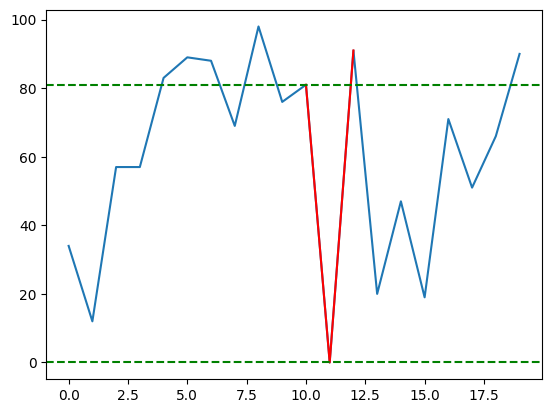

In [1]:
import matplotlib.pyplot as plt
import random

rand_nums = [random.randint(0, 100) for i in range(20)]

def find_all_pits(arr):
    pits = []
    n = len(arr)

    for i in range(1, n - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:

            left = i
            while left > 0 and arr[left] < arr[left - 1]:
                left -= 1
            right = i
            while right < n - 1 and arr[right] < arr[right + 1]:
                right += 1

            level = min(arr[left], arr[right])
            volume = sum(max(0, level - arr[j]) for j in range(left + 1, right))
            pits.append((left, right, volume))
    return pits

def find_largest_pit(arr):
    pits = find_all_pits(arr)
    if not pits:
        return None, None, 0
    largest_pit = max(pits, key=lambda x: x[2])
    return largest_pit

left_border, right_border, max_volume = find_largest_pit(rand_nums)
print(f"left_border = {left_border}, right_border = {right_border}")

if left_border is not None and right_border is not None:
    x = list(range(left_border, right_border + 1))
    y = [rand_nums[i] for i in x]

    min_border_level = min(rand_nums[left_border], rand_nums[right_border])
    plt.plot(rand_nums)
    plt.plot(x, y, color='red')
    plt.axhline(min(y), color='green', linestyle='--')
    plt.axhline(min_border_level, color='green', linestyle='--')
    plt.show()